<a href="https://colab.research.google.com/github/SSClements/INDE2000-Project/blob/main/INDE2000_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Library used**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# **Import Data**

In [3]:
file_names = [
    '2010-2011 Solar home electricity data.csv',
    '2011-2012 Solar home electricity data v2.csv',
    '2012-2013 Solar home electricity data v2.csv'
]

all_years_list = []

for name in file_names:

    try:
        # header=1 to skip the PDF description row
        temp_df = pd.read_csv(name, header=1)

        # Clean column names just in case
        temp_df.columns = [str(col).strip().lower() for col in temp_df.columns]

        # Find 'Date' and 'Category' by position or keyword
        date_col = next((c for c in temp_df.columns if 'date' in c), None)
        cat_col = next((c for c in temp_df.columns if 'consumption' in c or 'category' in c), None)

        if not date_col or not cat_col:
            print(f"Skipping {name}: Missing Date/Category columns.")
            continue

        # Select 48 columns by position (The last 48 columns)
        # In Ausgrid files, the 48 half-hour slots are always the last 48 columns.
        # Take the last 48 columns and rename them to 1-48 for consistency.
        power_data_cols = temp_df.columns[-48:].tolist()

        # Filter for General Consumption (GC)
        temp_gc = temp_df[temp_df[cat_col].astype(str).str.contains('GC', case=False, na=False)].copy()

        # Ensure data is numeric
        for col in power_data_cols:
            temp_gc[col] = pd.to_numeric(temp_gc[col], errors='coerce')

        # Aggregate: Mean of ALL customers
        daily_avg = temp_gc.groupby(date_col)[power_data_cols].mean().reset_index()

        # Rename columns to standard: 'Date', '1', '2', ..., '48'
        standard_names = ['Date'] + [str(i) for i in range(1, 49)]
        daily_avg.columns = standard_names

        all_years_list.append(daily_avg)
        print(f"SUCCESS: Processed {name} with 48 time slots.")

        del temp_df, temp_gc

    except Exception as e:
        print(f"Error at {name}: {e}")


SUCCESS: Processed 2010-2011 Solar home electricity data.csv with 48 time slots.
SUCCESS: Processed 2011-2012 Solar home electricity data v2.csv with 48 time slots.
SUCCESS: Processed 2012-2013 Solar home electricity data v2.csv with 48 time slots.


# **Transformation, Deseasonalization and Visualization**

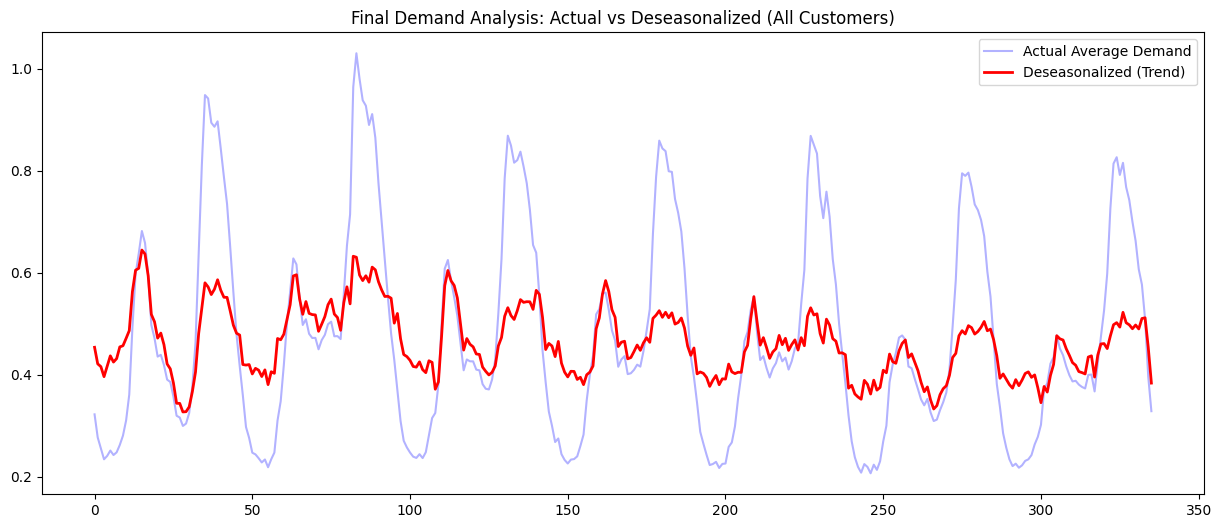

In [4]:
if all_years_list:
    df_combined = pd.concat(all_years_list, ignore_index=True)

    # Transformation
    time_periods = [str(i) for i in range(1, 49)]
    df_long = df_combined.melt(id_vars=['Date'], value_vars=time_periods,
                               var_name='Period', value_name='Avg_kWh')

    df_long['Date'] = pd.to_datetime(df_long['Date'], dayfirst=True)
    df_long['Period'] = df_long['Period'].astype(int)
    df_long = df_long.sort_values(['Date', 'Period']).reset_index(drop=True)

    # Deseasonalization (Lecture 6)
    grand_mean = df_long['Avg_kWh'].mean()
    seasonal_indices = df_long.groupby('Period')['Avg_kWh'].mean() / grand_mean
    df_long['Seasonal_Index'] = df_long['Period'].map(seasonal_indices)
    df_long['Deseasonalized_kWh'] = df_long['Avg_kWh'] / df_long['Seasonal_Index']

    # Visualization
    plt.figure(figsize=(15, 6))
    plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='blue', alpha=0.3)
    plt.plot(df_long['Deseasonalized_kWh'][:336], label='Deseasonalized (Trend)', color='red', linewidth=2)
    plt.title('Final Demand Analysis: Actual vs Deseasonalized (All Customers)')
    plt.legend()
    plt.show()
else:
    print("Check if your files are actually .csv and have 48 data columns at the end.")

In [5]:
# Counting NA values for total data
na_count = df_long['Avg_kWh'].isna().sum()
total_count = len(df_long)
na_pct = (na_count / total_count) * 100
print(f"Missing values (NA): {na_count} out of {total_count} ({na_pct:.2f}%)")

# Document Data
## Total Entries, Missing Data, Percentage
for i, df in enumerate(all_years_list):
    year_label = file_names[i].split('/')[-1][:9]

    non_missing = df.iloc[:, 1:].count().sum()
    total_cells = df.iloc[:, 1:].size
    missing = total_cells - non_missing
    missing_pct = (missing / total_cells) * 100

    print(f"  {year_label} | Total: {total_cells} | Missing: {missing} | ({missing_pct:.2f}%)")


Missing values (NA): 731 out of 52608 (1.39%)
  2010-2011 | Total: 17520 | Missing: 0 | (0.00%)
  2011-2012 | Total: 17568 | Missing: 366 | (2.08%)
  2012-2013 | Total: 17520 | Missing: 365 | (2.08%)


In [6]:
# Outliers
mean_val = df_long['Deseasonalized_kWh'].mean()
std_val = df_long['Deseasonalized_kWh'].std()
outliers = df_long[(df_long['Deseasonalized_kWh'] < mean_val - 3*std_val) |
                   (df_long['Deseasonalized_kWh'] > mean_val + 3*std_val)]

total_count = len(df_long)
print(f"Outliers (±3 std): {len(outliers)} out of {total_count} ({(len(outliers)/total_count)*100:.2f}%)")



Outliers (±3 std): 631 out of 52608 (1.20%)


In [7]:
print(outliers[['Date', 'Period', 'Avg_kWh', 'Deseasonalized_kWh']].sort_values('Deseasonalized_kWh', ascending=False).head(20))

            Date  Period   Avg_kWh  Deseasonalized_kWh
10541 2011-02-05      30  1.286773            1.385441
10540 2011-02-05      29  1.235820            1.349161
10542 2011-02-05      31  1.300290            1.347914
10539 2011-02-05      28  1.210897            1.317120
10538 2011-02-05      27  1.203817            1.295787
10543 2011-02-05      32  1.329047            1.291208
10537 2011-02-05      26  1.166850            1.254165
10536 2011-02-05      25  1.118087            1.192858
10544 2011-02-05      33  1.334213            1.169576
10535 2011-02-05      24  1.071133            1.155227
44764 2013-01-18      29  1.010530            1.103209
10534 2011-02-05      23  0.985903            1.079880
44765 2013-01-18      30  1.000880            1.077626
10585 2011-02-06      26  0.989167            1.063186
44766 2013-01-18      31  1.002337            1.039048
10584 2011-02-06      25  0.969457            1.034289
44285 2013-01-08      30  0.949737            1.022561
44763 2013

Outliers are during peak summer season, keep them in

# Model Formulation

hi these models are currently just using all three years to be created and then plotting their predictions of those same three years. I have not done a train/test split ratio to test accuracy of forecasting future data


also please let me know if it looks wrong or you think we should approach differently


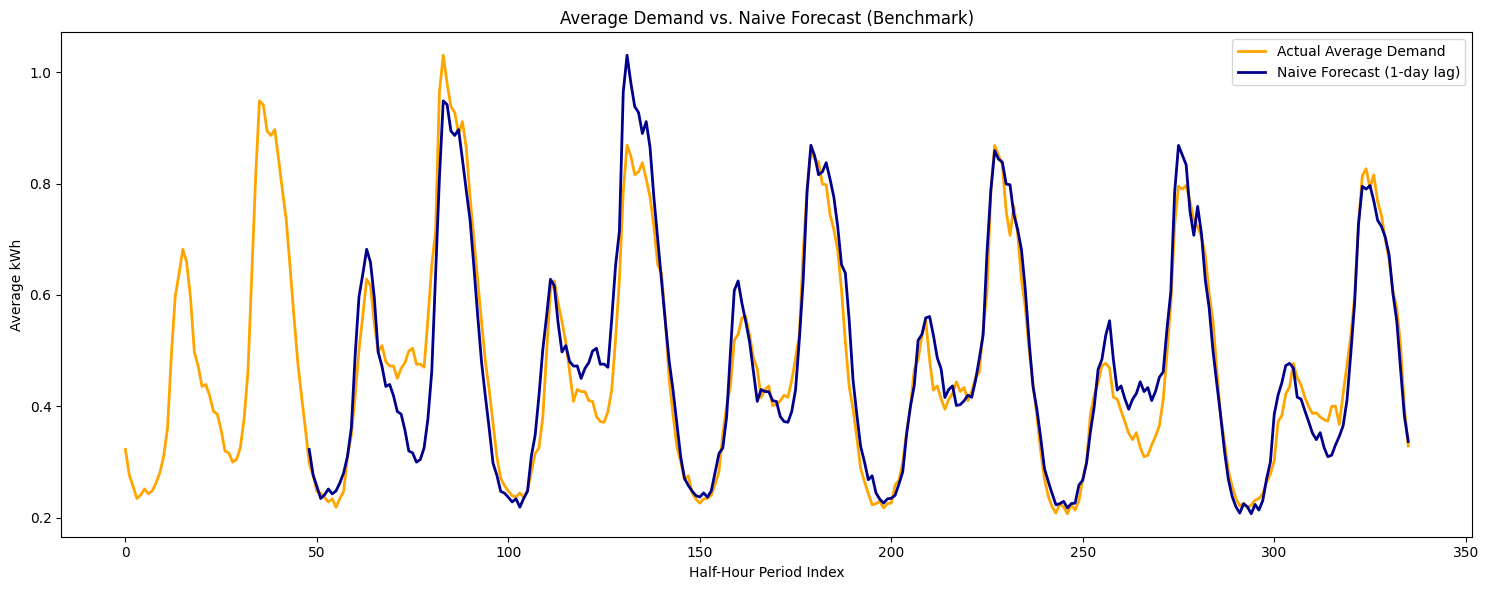

In [8]:
# Naive Forecast

# Shift by 48 periods (one full day of 30-min intervals)
df_long['Naive_Deseasonalized'] = df_long['Deseasonalized_kWh'].shift(48)

# Re-seasonalize
df_long['Naive'] = df_long['Naive_Deseasonalized'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='orange', linewidth=2)
plt.plot(df_long['Naive'][:336], label='Naive Forecast (1-day lag)', color='darkblue', linewidth=2)
plt.title('Average Demand vs. Naive Forecast (Benchmark)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

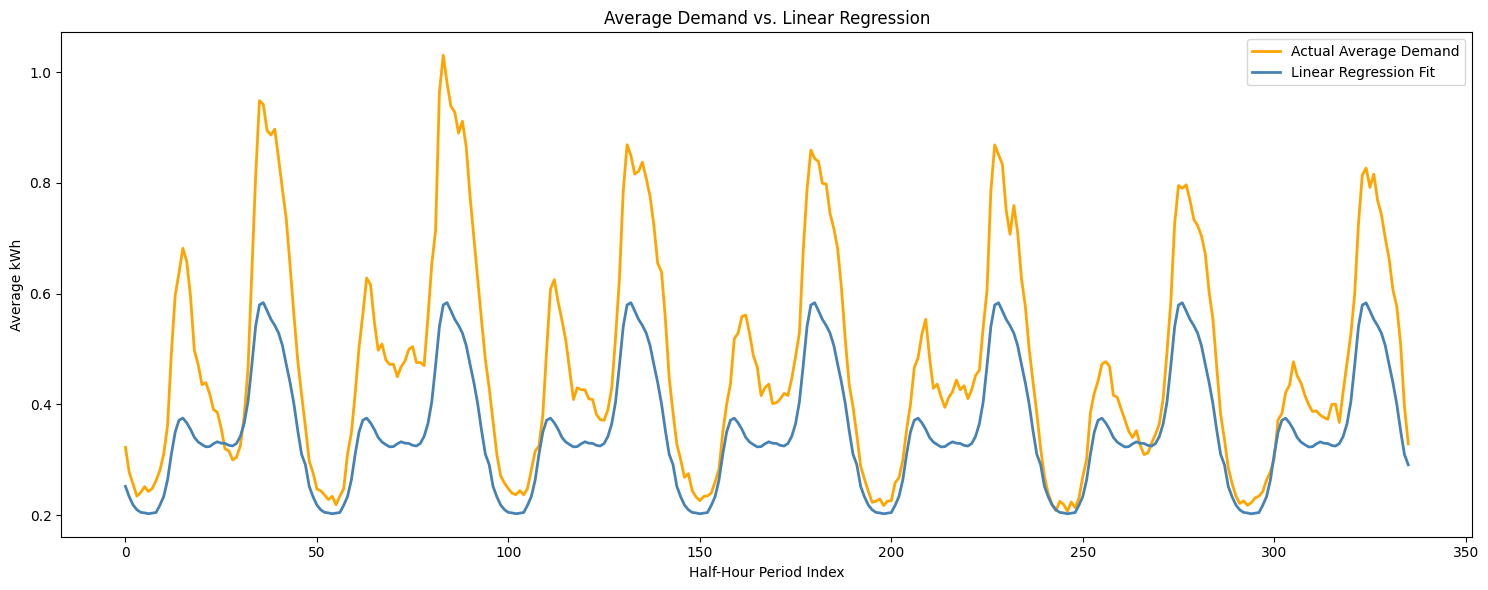

In [9]:
# Linear Regression

# Drop NaNs and reset index so X and y align
mask = df_long['Deseasonalized_kWh'].notna()
y = df_long.loc[mask, 'Deseasonalized_kWh'].astype(float).reset_index(drop=True)

t_vals = np.arange(mask.sum())
period_dummies = pd.get_dummies(df_long.loc[mask, 'Period'], prefix='P', drop_first=True).astype(float).reset_index(drop=True)

X = pd.concat([pd.Series(t_vals, name='t'), period_dummies], axis=1)
X = sm.add_constant(X)

model_lr = sm.OLS(y, X).fit()

# Store fitted values and re-seasonalize

df_long['LR_Deseasonalized'] = model_lr.fittedvalues
df_long['LR'] = df_long['LR_Deseasonalized'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='orange', linewidth=2)
plt.plot(df_long['LR'][:336], label='Linear Regression Fit', color='steelblue', linewidth=2)
plt.title('Average Demand vs. Linear Regression')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

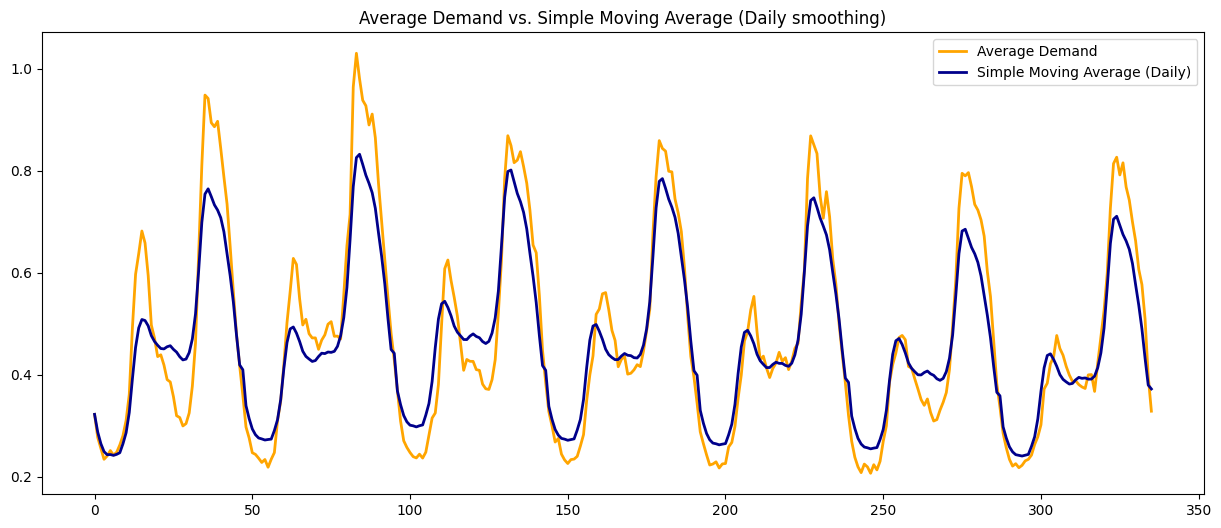

In [10]:
# Simple Moving Average

## One day smoothing (30 min intervals)
df_long['SMA_48_Deseasonalized'] = df_long.Deseasonalized_kWh.rolling(48, min_periods=1).mean()

## Re-seasonalisation
df_long['SMA_48'] = df_long['SMA_48_Deseasonalized'] * df_long['Seasonal_Index']

# Simple Moving Average Plot

plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['SMA_48'][:336], label='Simple Moving Average (Daily)', color='darkblue', linewidth=2)
plt.title('Average Demand vs. Simple Moving Average (Daily smoothing)')
plt.legend()
plt.show()

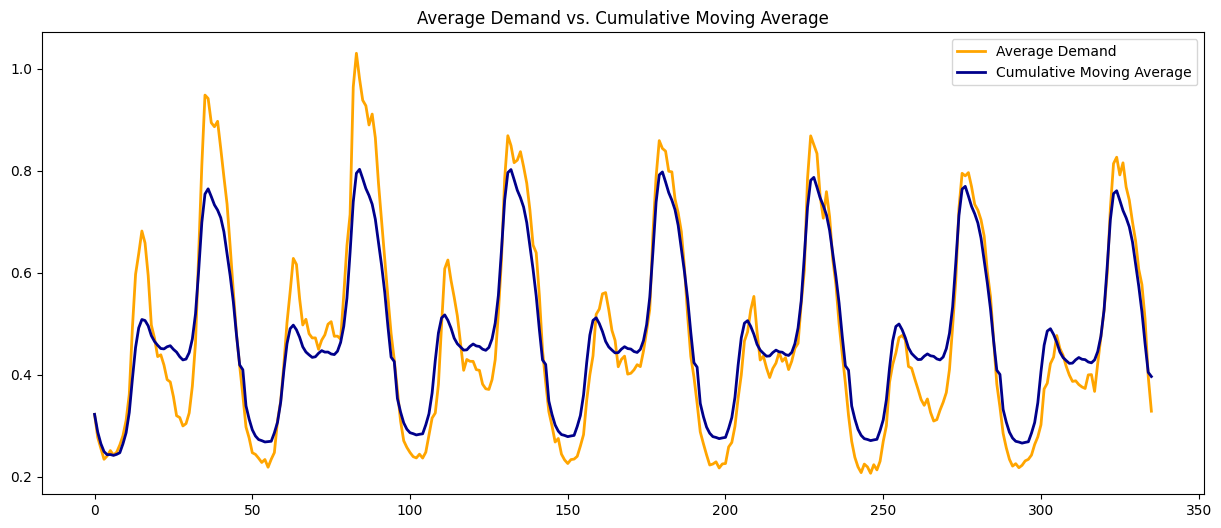

In [11]:
# Cumulative Moving Average

df_long['CMA_Deseasonalized'] = df_long.Deseasonalized_kWh.expanding().mean()

## Re-seasonalisation
df_long['CMA'] = df_long['CMA_Deseasonalized'] * df_long['Seasonal_Index']


plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['CMA'][:336], label='Cumulative Moving Average', color='darkblue', linewidth=2)
plt.title('Average Demand vs. Cumulative Moving Average')
plt.legend()
plt.show()

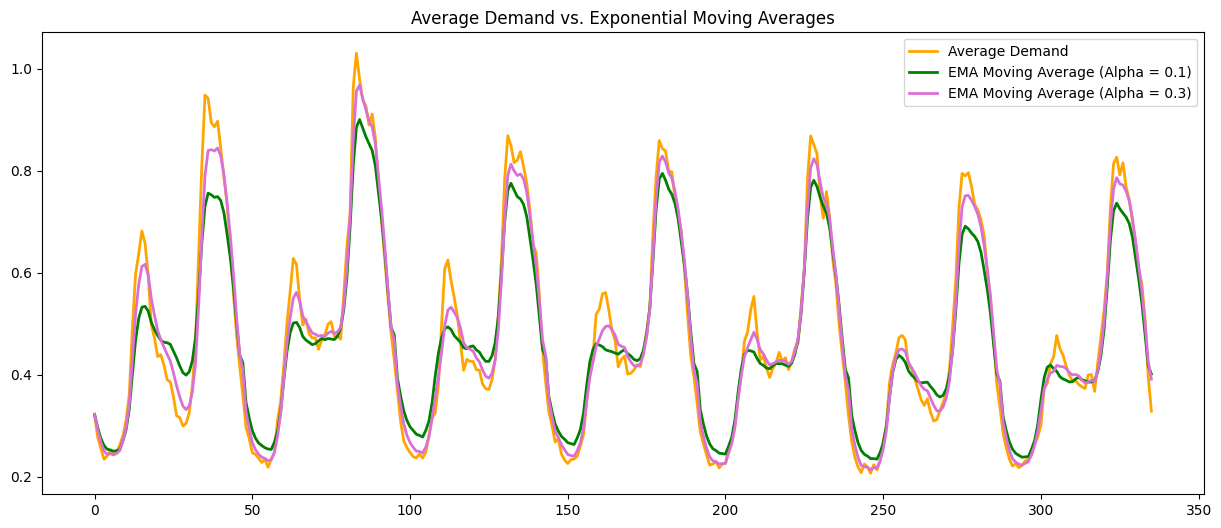

In [12]:
# Exponential Moving Average

df_long['EMA_0.1_Deseasonalized'] = df_long.Deseasonalized_kWh.ewm(alpha=0.1, adjust = False).mean()
df_long['EMA_0.3_Deseasonalized'] = df_long.Deseasonalized_kWh.ewm(alpha=0.3, adjust = False).mean()

## Re-seasonalisation
df_long['EMA_0.1'] = df_long['EMA_0.1_Deseasonalized'] * df_long['Seasonal_Index']
df_long['EMA_0.3'] = df_long['EMA_0.3_Deseasonalized'] * df_long['Seasonal_Index']


plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['EMA_0.1'][:336], label='EMA Moving Average (Alpha = 0.1)', color='green', linewidth=2)
plt.plot(df_long['EMA_0.3'][:336], label='EMA Moving Average (Alpha = 0.3)', color='orchid', linewidth=2)
plt.title('Average Demand vs. Exponential Moving Averages')
plt.legend()
plt.show()

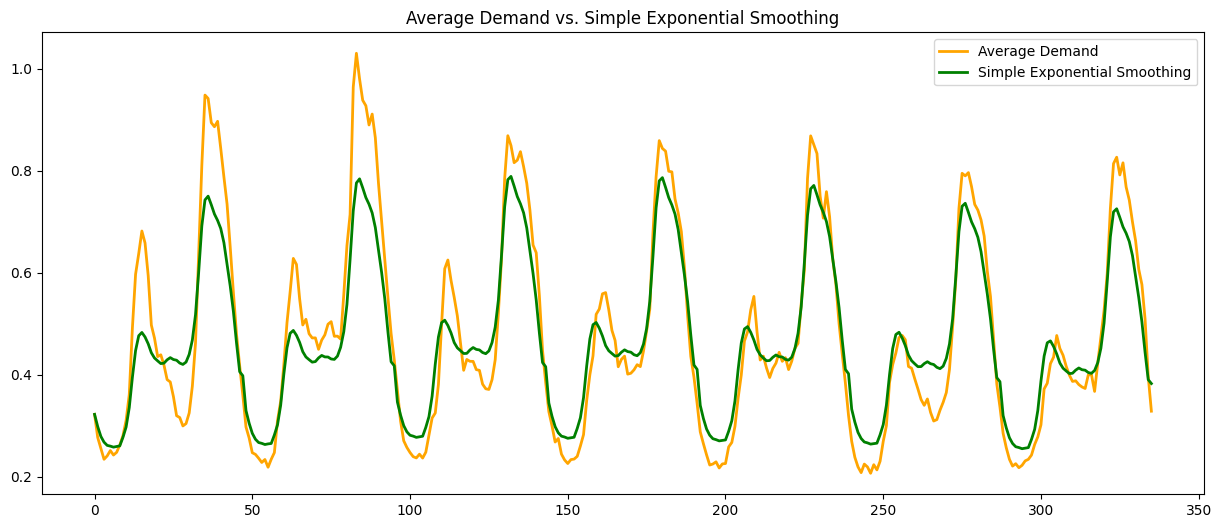

In [13]:
# Simple Exponential Smoothing

m = 48   # daily
alpha = 1/(2*m)
alpha

df_long['SES_Deseasonalised'] = SimpleExpSmoothing(df_long['Deseasonalized_kWh']).fit(smoothing_level=alpha,optimized=False,use_brute=True).fittedvalues

## Reseasonalized
df_long['SES'] = df_long['SES_Deseasonalised'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['SES'][:336], label='Simple Exponential Smoothing', color='green', linewidth=2)
plt.title('Average Demand vs. Simple Exponential Smoothing')
plt.legend()
plt.show()

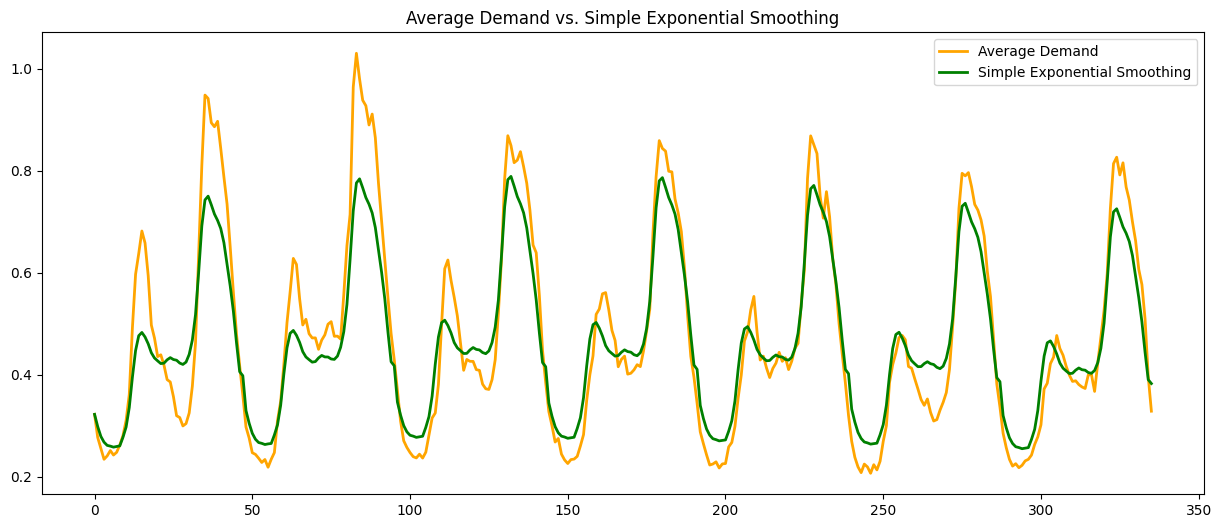

In [14]:
# Simple Exponential Smoothing (Single HWES)

m = 48   # daily
alpha = 1/(2*m)
alpha

df_long['SES_Deseasonalised'] = SimpleExpSmoothing(df_long['Deseasonalized_kWh']).fit(smoothing_level=alpha,optimized=False,use_brute=True).fittedvalues

## Reseasonalized
df_long['SES'] = df_long['SES_Deseasonalised'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['SES'][:336], label='Simple Exponential Smoothing', color='green', linewidth=2)
plt.title('Average Demand vs. Simple Exponential Smoothing')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


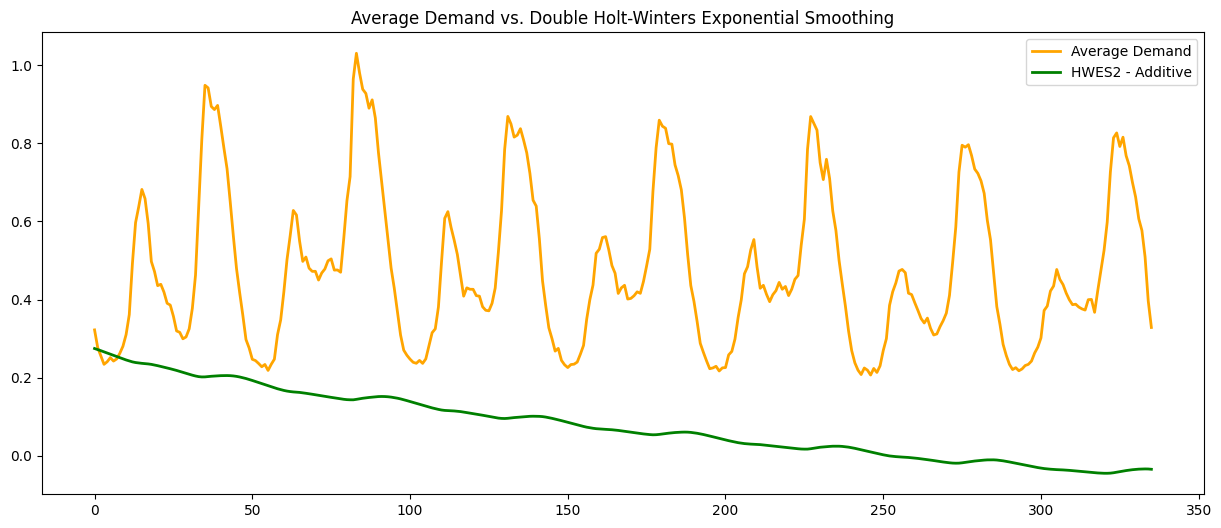

In [15]:
# Double Holt-Winters Exponential Smoothing

df_long['HWES2_ADD'] = ExponentialSmoothing(df_long['Avg_kWh'], trend = 'add').fit().fittedvalues

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['HWES2_ADD'][:336], label='HWES2 - Additive', color='green', linewidth=2)
plt.title('Average Demand vs. Double Holt-Winters Exponential Smoothing')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


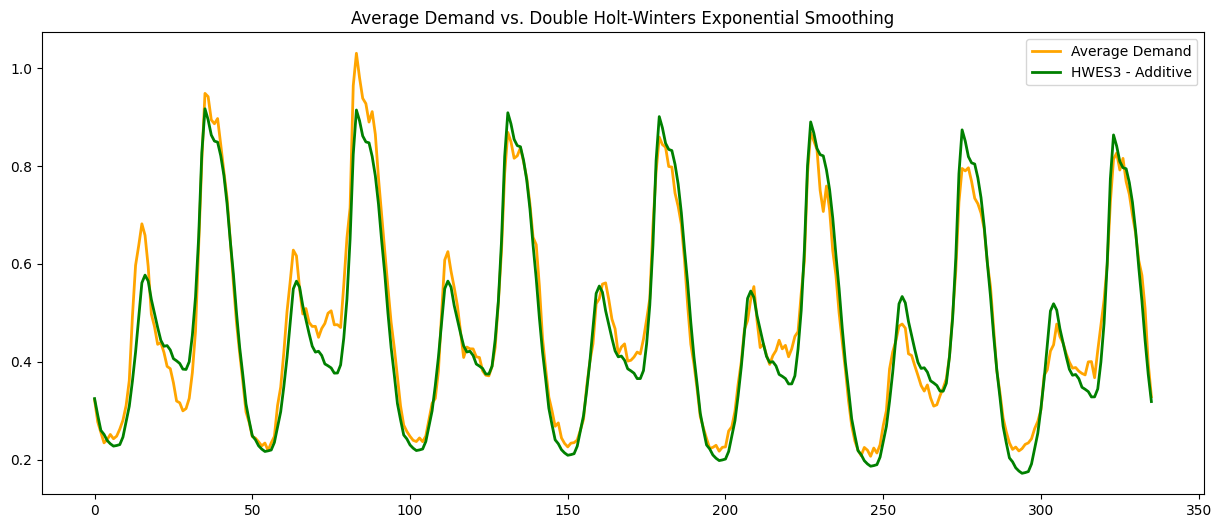

In [16]:
# Triple Holt-Winters Exponential Smoothing
df_long['HWES3_ADD'] = ExponentialSmoothing(df_long['Avg_kWh'], trend = 'add', seasonal='add', seasonal_periods = 48).fit().fittedvalues

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['HWES3_ADD'][:336], label='HWES3 - Additive', color='green', linewidth=2)
plt.title('Average Demand vs. Double Holt-Winters Exponential Smoothing')
plt.legend()
plt.show()

In [17]:
zero_rows = df_long[df_long['Avg_kWh'] == 0]
print(zero_rows[['Date', 'Period', 'Avg_kWh']])

            Date  Period  Avg_kWh
4516  2010-10-03       5      0.0
4517  2010-10-03       6      0.0
21987 2011-10-02       4      0.0
21988 2011-10-02       5      0.0
39795 2012-10-07       4      0.0
39796 2012-10-07       5      0.0


# **Split Ratio: 1st & 2nd Years Train / 3rd Year Test**

In [18]:
# ── Train / Test Split ───────────────────────────────────────────
# Train: Year 1 & 2  |  Test: Year 3

split_date = pd.Timestamp('2012-07-01')

train = df_long[df_long['Date'] < split_date].copy()
test  = df_long[df_long['Date'] >= split_date].copy()

print(f"Train size: {len(train)} | Date range: {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Test size:  {len(test)}  | Date range: {test['Date'].min().date()} → {test['Date'].max().date()}")

Train size: 35088 | Date range: 2010-07-01 → 2012-06-30
Test size:  17520  | Date range: 2012-07-01 → 2013-06-30


In [19]:
print("NaNs in test Deseasonalized_kWh:", df_long[df_long['Date'] >= split_date]['Deseasonalized_kWh'].isna().sum())
print("Total test rows:", len(df_long[df_long['Date'] >= split_date]))

NaNs in test Deseasonalized_kWh: 365
Total test rows: 17520


In [20]:
test_check = df_long[df_long['Date'] >= split_date].copy()
nan_periods = test_check[test_check['Deseasonalized_kWh'].isna()]['Period'].value_counts()
print(nan_periods)

Period
48    365
Name: count, dtype: int64


In [21]:
# ── Fill missing Period 48 in test set ───────────────────────────
# Period 48 is missing every day in year 3 — interpolate from Period 47 and next day Period 1

df_long['Deseasonalized_kWh'] = df_long['Deseasonalized_kWh'].interpolate(method='linear')
df_long['Avg_kWh'] = df_long['Avg_kWh'].interpolate(method='linear')

# Verify
print("NaNs remaining:", df_long[df_long['Date'] >= split_date]['Deseasonalized_kWh'].isna().sum())

NaNs remaining: 0


## **Naive**

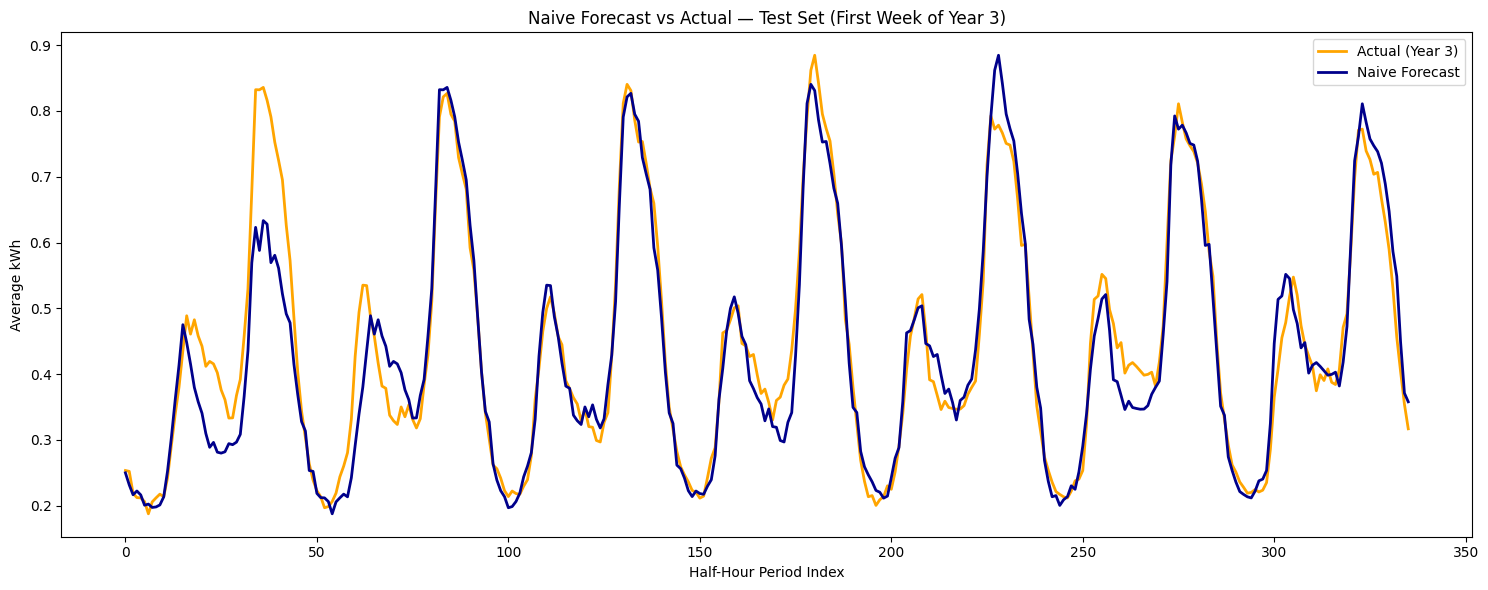

In [22]:
# ── Naive Forecast (Benchmark) ───────────────────────────────────
# Seasonal naive: forecast = same period from 1 day ago (48 step lag)

df_long['Naive_Deseasonalized'] = df_long['Deseasonalized_kWh'].shift(48)
df_long['Naive'] = df_long['Naive_Deseasonalized'] * df_long['Seasonal_Index']

# Pull out test portion
test_naive = df_long[df_long['Date'] >= split_date].copy()

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_naive['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_naive['Naive'].values[:336],   label='Naive Forecast', color='darkblue', linewidth=2)
plt.title('Naive Forecast vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ── Naive Accuracy (Test Set Only) ───────────────────────────────

test_naive_clean = test_naive.dropna(subset=['Naive', 'Avg_kWh'])
errors_naive = test_naive_clean['Avg_kWh'] - test_naive_clean['Naive']

Bias_naive  = errors_naive.mean()
MAD_naive   = errors_naive.abs().mean()
MAPE_naive  = (errors_naive.abs() / test_naive_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_naive  = np.sqrt((errors_naive ** 2).mean())
TS_naive    = Bias_naive / MAD_naive

print("=== Naive Forecast (Benchmark) — Test Set Accuracy ===")
print(f"  Bias : {Bias_naive:.4f} kWh")
print(f"  MAD  : {MAD_naive:.4f} kWh")
print(f"  MAPE : {MAPE_naive:.2f}%")
print(f"  RMSE : {RMSE_naive:.4f} kWh")
print(f"  TS   : {TS_naive:.4f}")

=== Naive Forecast (Benchmark) — Test Set Accuracy ===
  Bias : -0.0003 kWh
  MAD  : 0.0365 kWh
  MAPE : 10.75%
  RMSE : 0.0699 kWh
  TS   : -0.0069


## **Simple Moving Average**

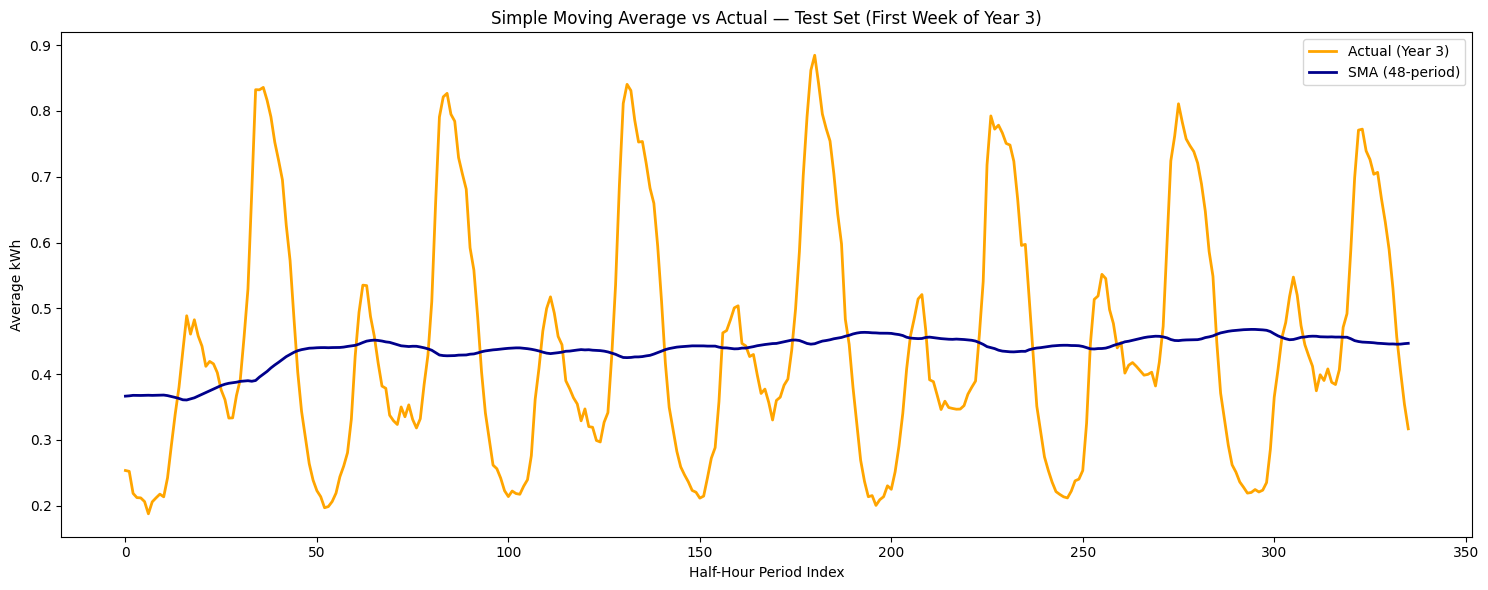

In [24]:
# ── Simple Moving Average Fixed ───────────────────────────────────

train_sma = df_long[df_long['Date'] < split_date].copy().reset_index(drop=True)
test_sma  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

# Use Avg_kWh directly instead of Deseasonalized_kWh
clean_train = train_sma['Avg_kWh'].dropna()
seed = clean_train.iloc[-47:].tolist()
window = seed.copy()
sma_values = []

for val in test_sma['Avg_kWh']:
    sma_values.append(np.mean(window))
    if pd.notna(val):
        window.append(val)
        window.pop(0)

# No re-seasonalization needed
test_sma['SMA_48'] = sma_values

plt.figure(figsize=(15, 6))
plt.plot(test_sma['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_sma['SMA_48'].values[:336],  label='SMA (48-period)', color='darkblue', linewidth=2)
plt.title('Simple Moving Average vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# ── SMA Accuracy (Test Set Only) ─────────────────────────────────

errors_sma = test_sma['Avg_kWh'] - test_sma['SMA_48']
Bias_sma = errors_sma.mean()
MAD_sma  = errors_sma.abs().mean()
MAPE_sma = (errors_sma.abs() / test_sma['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_sma = np.sqrt((errors_sma ** 2).mean())
TS_sma   = Bias_sma / MAD_sma

print("=== Simple Moving Average Fixed — Test Set Accuracy ===")
print(f"  Bias : {Bias_sma:.4f} kWh")
print(f"  MAD  : {MAD_sma:.4f} kWh")
print(f"  MAPE : {MAPE_sma:.2f}%")
print(f"  RMSE : {RMSE_sma:.4f} kWh")
print(f"  TS   : {TS_sma:.4f}")

=== Simple Moving Average Fixed — Test Set Accuracy ===
  Bias : 0.0001 kWh
  MAD  : 0.0911 kWh
  MAPE : 30.26%
  RMSE : 0.1189 kWh
  TS   : 0.0012


## **Cumulative Moving Average**

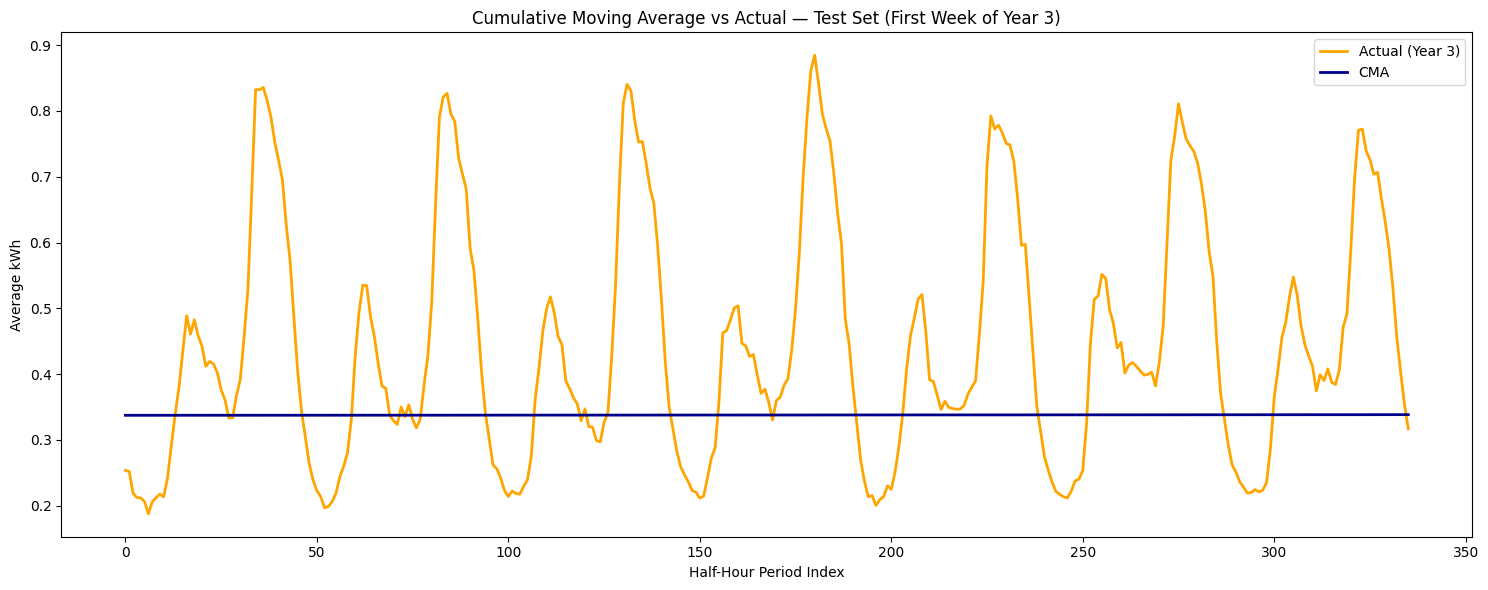

In [26]:
# ── Cumulative Moving Average Fixed ───────────────────────────────

train_cma = df_long[df_long['Date'] < split_date].copy().reset_index(drop=True)
test_cma  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

clean_train = train_cma['Avg_kWh'].dropna()
running_sum   = clean_train.sum()
running_count = clean_train.count()

cma_values = []
for val in test_cma['Avg_kWh']:
    cma_values.append(running_sum / running_count)
    if pd.notna(val):
        running_sum   += val
        running_count += 1

test_cma['CMA'] = cma_values

plt.figure(figsize=(15, 6))
plt.plot(test_cma['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_cma['CMA'].values[:336],     label='CMA', color='darkblue', linewidth=2)
plt.title('Cumulative Moving Average vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# ── CMA Accuracy (Test Set Only) ─────────────────────────────────

errors_cma = test_cma['Avg_kWh'] - test_cma['CMA']
Bias_cma = errors_cma.mean()
MAD_cma  = errors_cma.abs().mean()
MAPE_cma = (errors_cma.abs() / test_cma['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_cma = np.sqrt((errors_cma ** 2).mean())
TS_cma   = Bias_cma / MAD_cma

print("=== Cumulative Moving Average Fixed — Test Set Accuracy ===")
print(f"  Bias : {Bias_cma:.4f} kWh")
print(f"  MAD  : {MAD_cma:.4f} kWh")
print(f"  MAPE : {MAPE_cma:.2f}%")
print(f"  RMSE : {RMSE_cma:.4f} kWh")
print(f"  TS   : {TS_cma:.4f}")

=== Cumulative Moving Average Fixed — Test Set Accuracy ===
  Bias : -0.0160 kWh
  MAD  : 0.1011 kWh
  MAPE : 35.24%
  RMSE : 0.1302 kWh
  TS   : -0.1587


## **Exponential Moving Average**

Optimal Alpha: 0.9900


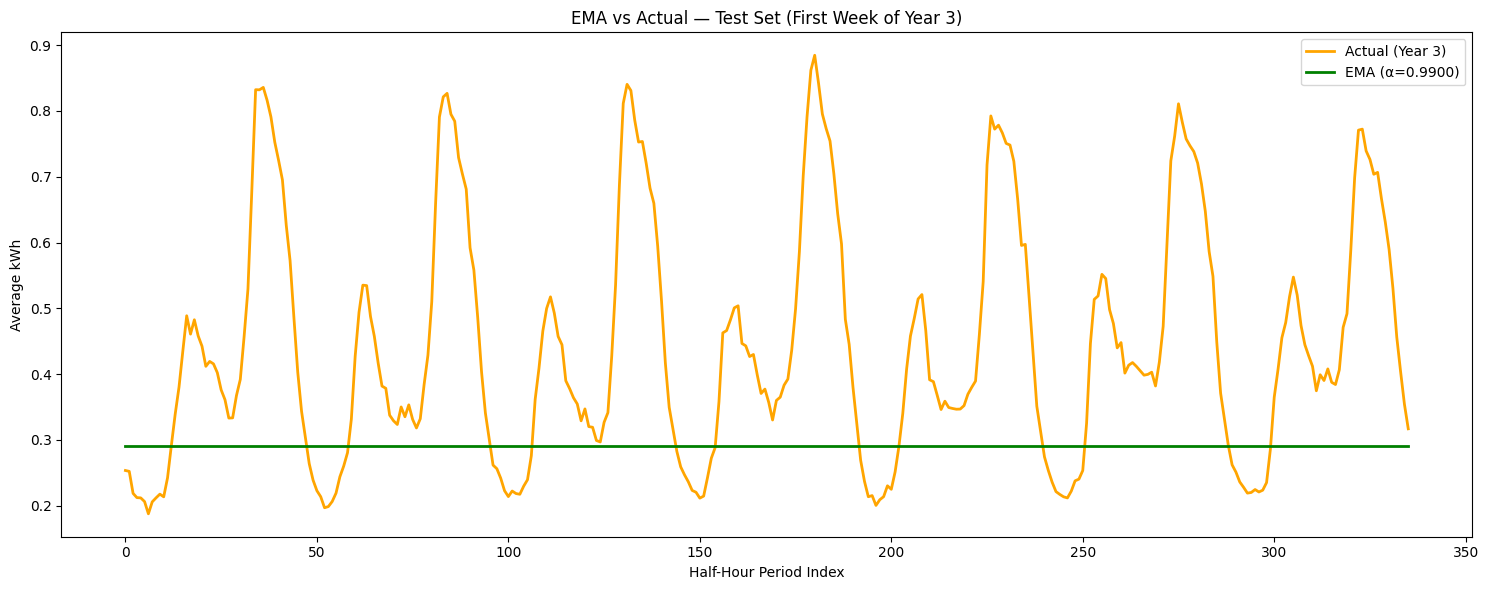

In [28]:
# ── EMA Fixed ─────────────────────────────────────────────────────

train_ema = df_long[df_long['Date'] < split_date].copy().reset_index(drop=True)
test_ema  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

def ema_rmse(alpha):
    ema = train_ema['Avg_kWh'].ewm(alpha=alpha, adjust=False).mean()
    errors = train_ema['Avg_kWh'] - ema
    return np.sqrt((errors ** 2).mean())

from scipy.optimize import minimize_scalar
result = minimize_scalar(ema_rmse, bounds=(0.01, 0.99), method='bounded')
best_alpha = result.x
print(f"Optimal Alpha: {best_alpha:.4f}")

last_ema = train_ema['Avg_kWh'].ewm(alpha=best_alpha, adjust=False).mean().iloc[-1]
test_ema['EMA_best'] = last_ema

plt.figure(figsize=(15, 6))
plt.plot(test_ema['Avg_kWh'].values[:336],  label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_ema['EMA_best'].values[:336], label=f'EMA (α={best_alpha:.4f})', color='green', linewidth=2)
plt.title('EMA vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# ── EMA Accuracy (Test Set Only) ─────────────────────────────────

errors_ema = test_ema['Avg_kWh'] - test_ema['EMA_best']
Bias_ema = errors_ema.mean()
MAD_ema  = errors_ema.abs().mean()
MAPE_ema = (errors_ema.abs() / test_ema['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_ema = np.sqrt((errors_ema ** 2).mean())
TS_ema   = Bias_ema / MAD_ema

print(f"=== EMA (α={best_alpha:.4f}) Fixed — Test Set Accuracy ===")
print(f"  Bias : {Bias_ema:.4f} kWh")
print(f"  MAD  : {MAD_ema:.4f} kWh")
print(f"  MAPE : {MAPE_ema:.2f}%")
print(f"  RMSE : {RMSE_ema:.4f} kWh")
print(f"  TS   : {TS_ema:.4f}")

=== EMA (α=0.9900) Fixed — Test Set Accuracy ===
  Bias : 0.0283 kWh
  MAD  : 0.0928 kWh
  MAPE : 28.21%
  RMSE : 0.1324 kWh
  TS   : 0.3044


## **Simple Exponential Smoothing**

Optimal Alpha (SES): 1.0000


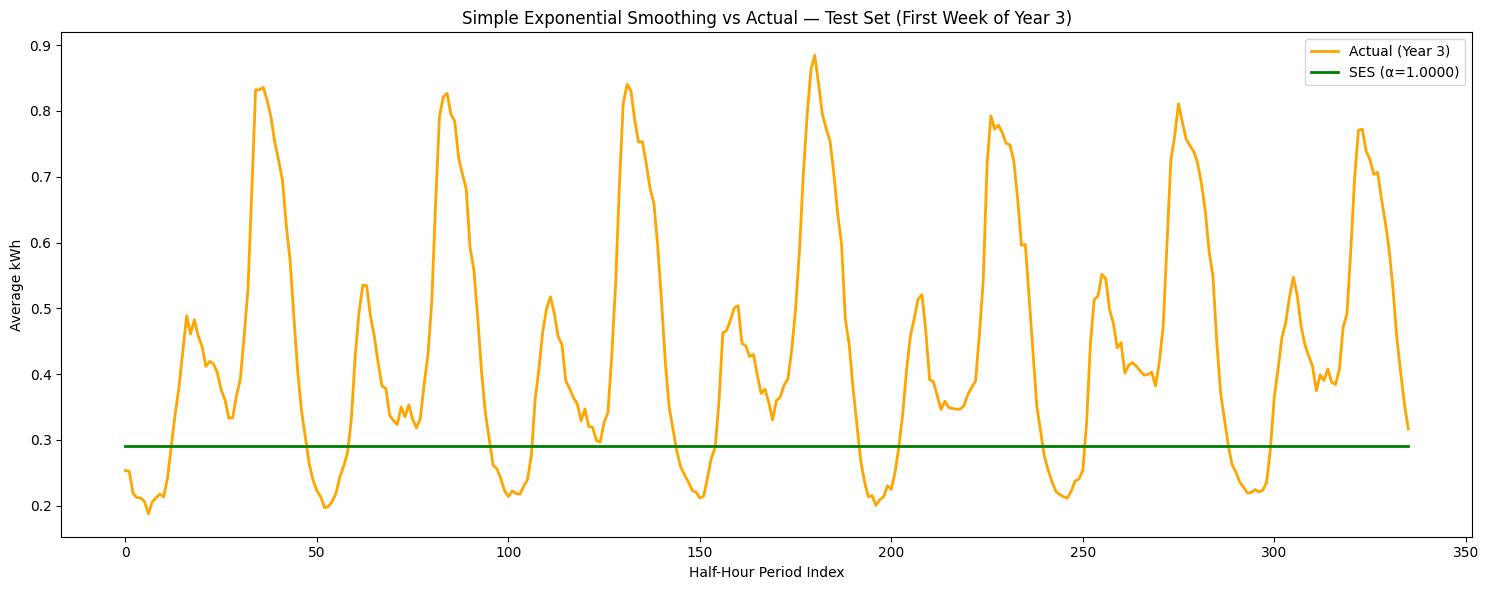

In [30]:
# ── Simple Exponential Smoothing (Train/Test Split) ───────────────

train_ses = df_long[df_long['Date'] < split_date]['Avg_kWh'].dropna().reset_index(drop=True)
test_ses  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

ses_model = SimpleExpSmoothing(train_ses).fit(optimized=True)
best_alpha_ses = ses_model.params['smoothing_level']
print(f"Optimal Alpha (SES): {best_alpha_ses:.4f}")

ses_forecast = ses_model.forecast(len(test_ses)).reset_index(drop=True)
test_ses['SES'] = ses_forecast.values

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_ses['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_ses['SES'].values[:336],     label=f'SES (α={best_alpha_ses:.4f})', color='green', linewidth=2)
plt.title('Simple Exponential Smoothing vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# ── SES Accuracy (Test Set Only) ─────────────────────────────────

test_ses_clean = test_ses.dropna(subset=['SES', 'Avg_kWh'])
errors_ses = test_ses_clean['Avg_kWh'] - test_ses_clean['SES']

Bias_ses  = errors_ses.mean()
MAD_ses   = errors_ses.abs().mean()
MAPE_ses  = (errors_ses.abs() / test_ses_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_ses  = np.sqrt((errors_ses ** 2).mean())
TS_ses    = Bias_ses / MAD_ses

print(f"=== Simple Exponential Smoothing (α={best_alpha_ses:.4f}) — Test Set Accuracy ===")
print(f"  Bias : {Bias_ses:.4f} kWh")
print(f"  MAD  : {MAD_ses:.4f} kWh")
print(f"  MAPE : {MAPE_ses:.2f}%")
print(f"  RMSE : {RMSE_ses:.4f} kWh")
print(f"  TS   : {TS_ses:.4f}")

=== Simple Exponential Smoothing (α=1.0000) — Test Set Accuracy ===
  Bias : 0.0286 kWh
  MAD  : 0.0928 kWh
  MAPE : 28.16%
  RMSE : 0.1325 kWh
  TS   : 0.3085


## **Double Holt Winters**

Alpha: 1.0000
Beta : 0.7666


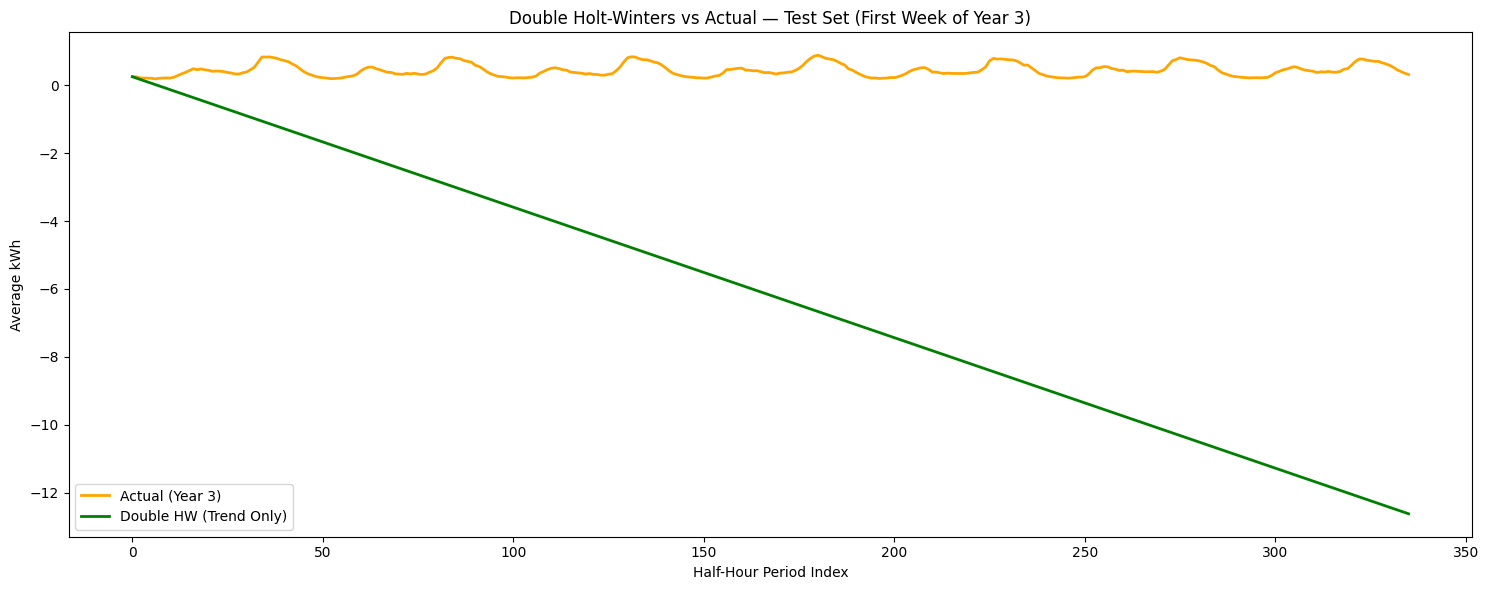

In [32]:
# ── Double Holt-Winters Fixed (deseasonalized) ────────────────────

train_hw2 = df_long[df_long['Date'] < split_date]['Avg_kWh'].dropna().reset_index(drop=True)
test_hw2  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

hw2_model = ExponentialSmoothing(train_hw2, trend='add').fit(optimized=True)
print(f"Alpha: {hw2_model.params['smoothing_level']:.4f}")
print(f"Beta : {hw2_model.params['smoothing_trend']:.4f}")

hw2_forecast = hw2_model.forecast(len(test_hw2)).reset_index(drop=True)
test_hw2['HWES2_ADD'] = hw2_forecast.values

plt.figure(figsize=(15, 6))
plt.plot(test_hw2['Avg_kWh'].values[:336],   label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_hw2['HWES2_ADD'].values[:336], label='Double HW (Trend Only)', color='green', linewidth=2)
plt.title('Double Holt-Winters vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# ── Double HW Accuracy (Test Set Only) ───────────────────────────

errors_hw2 = test_hw2['Avg_kWh'] - test_hw2['HWES2_ADD']
Bias_hw2 = errors_hw2.mean()
MAD_hw2  = errors_hw2.abs().mean()
MAPE_hw2 = (errors_hw2.abs() / test_hw2['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_hw2 = np.sqrt((errors_hw2 ** 2).mean())
TS_hw2   = Bias_hw2 / MAD_hw2

print("=== Double Holt-Winters Fixed — Test Set Accuracy ===")
print(f"  Bias : {Bias_hw2:.4f} kWh")
print(f"  MAD  : {MAD_hw2:.4f} kWh")
print(f"  MAPE : {MAPE_hw2:.2f}%")
print(f"  RMSE : {RMSE_hw2:.4f} kWh")
print(f"  TS   : {TS_hw2:.4f}")

=== Double Holt-Winters Fixed — Test Set Accuracy ===
  Bias : 336.8301 kWh
  MAD  : 336.8301 kWh
  MAPE : 121323.94%
  RMSE : 388.9193 kWh
  TS   : 1.0000


## **Triple Holt Winters**

Alpha (level)   : 0.7374
Beta  (trend)   : 0.0000
Gamma (seasonal): 0.2626


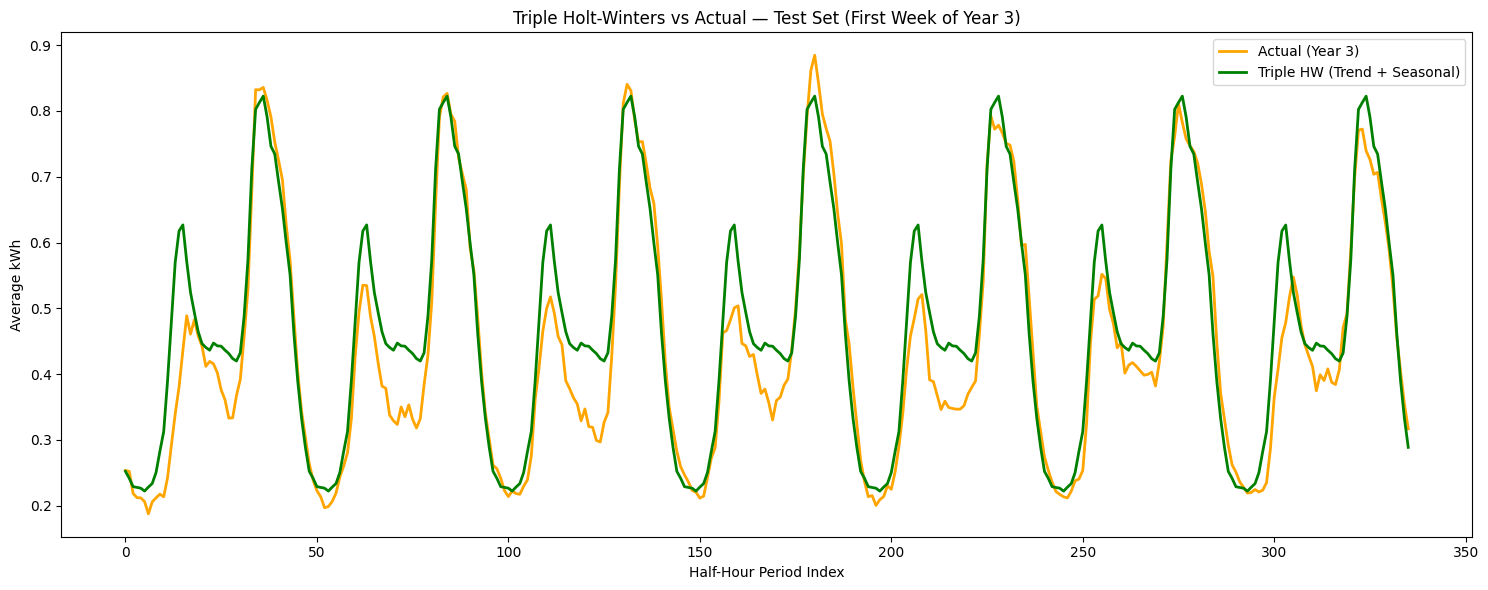

In [34]:
# ── Triple Holt-Winters Fixed (deseasonalized) ────────────────────

train_hw3 = df_long[df_long['Date'] < split_date]['Avg_kWh'].dropna().reset_index(drop=True)
test_hw3  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

hw3_model = ExponentialSmoothing(
    train_hw3,
    trend='add',
    seasonal='add',
    seasonal_periods=48
).fit(optimized=True)

print(f"Alpha (level)   : {hw3_model.params['smoothing_level']:.4f}")
print(f"Beta  (trend)   : {hw3_model.params['smoothing_trend']:.4f}")
print(f"Gamma (seasonal): {hw3_model.params['smoothing_seasonal']:.4f}")

hw3_forecast = hw3_model.forecast(len(test_hw3)).reset_index(drop=True)
test_hw3['HWES3_ADD'] = hw3_forecast.values

plt.figure(figsize=(15, 6))
plt.plot(test_hw3['Avg_kWh'].values[:336],   label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_hw3['HWES3_ADD'].values[:336], label='Triple HW (Trend + Seasonal)', color='green', linewidth=2)
plt.title('Triple Holt-Winters vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# ── Triple HW Accuracy (Test Set Only) ───────────────────────────

errors_hw3 = test_hw3['Avg_kWh'] - test_hw3['HWES3_ADD']
Bias_hw3 = errors_hw3.mean()
MAD_hw3  = errors_hw3.abs().mean()
MAPE_hw3 = (errors_hw3.abs() / test_hw3['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_hw3 = np.sqrt((errors_hw3 ** 2).mean())
TS_hw3   = Bias_hw3 / MAD_hw3

print("=== Triple Holt-Winters Fixed — Test Set Accuracy ===")
print(f"  Bias : {Bias_hw3:.4f} kWh")
print(f"  MAD  : {MAD_hw3:.4f} kWh")
print(f"  MAPE : {MAPE_hw3:.2f}%")
print(f"  RMSE : {RMSE_hw3:.4f} kWh")
print(f"  TS   : {TS_hw3:.4f}")

=== Triple Holt-Winters Fixed — Test Set Accuracy ===
  Bias : -0.1493 kWh
  MAD  : 0.1562 kWh
  MAPE : 51.51%
  RMSE : 0.1919 kWh
  TS   : -0.9557


## **Linear Regression**

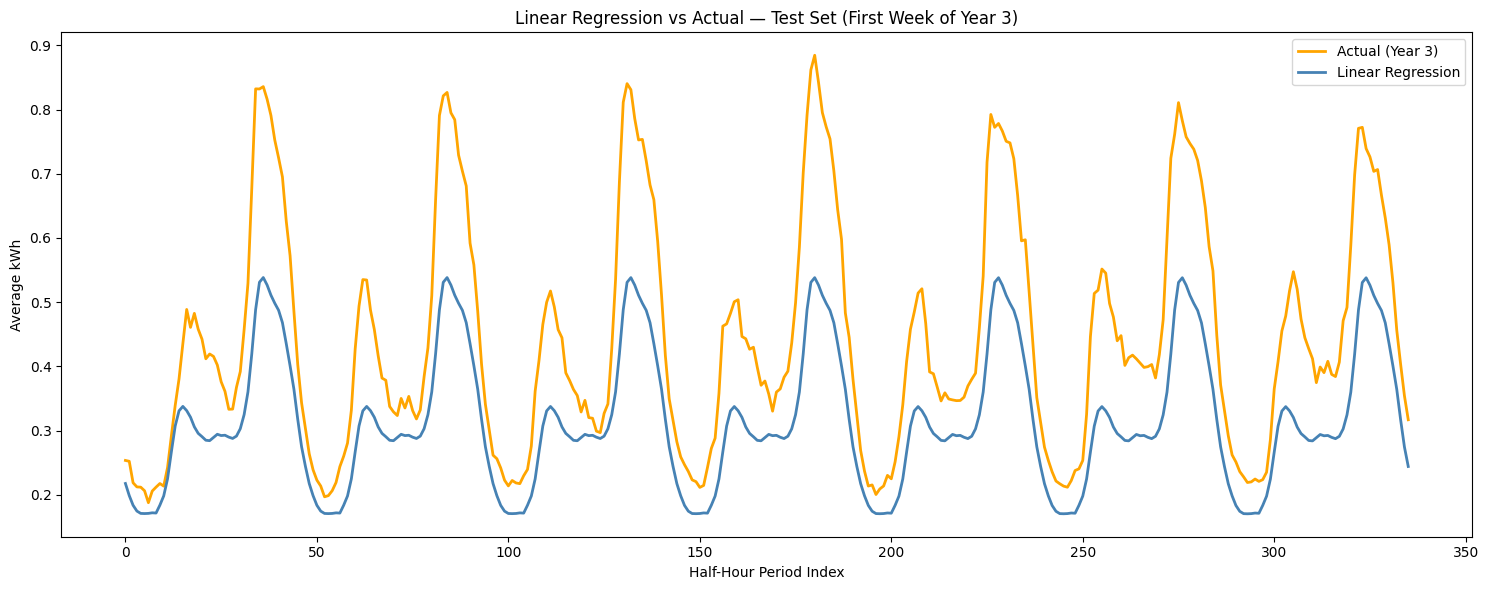

In [36]:
# ── Forecast on Test Set ──────────────────────────────────────────

train_lr = df_long[df_long['Date'] < split_date].copy().reset_index(drop=True)
test_lr  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

train_lr['t'] = np.arange(len(train_lr))
period_dummies_train = pd.get_dummies(train_lr['Period'], prefix='P', drop_first=True).astype(float)
X_train = pd.concat([train_lr[['t']], period_dummies_train], axis=1).astype(float)
X_train = sm.add_constant(X_train)

# Use Avg_kWh directly
y_train = train_lr['Avg_kWh'].astype(float)

mask = y_train.notna()
X_train = X_train[mask].reset_index(drop=True)
y_train = y_train[mask].reset_index(drop=True)

model_lr = sm.OLS(y_train, X_train).fit()

test_lr['t'] = np.arange(len(train_lr), len(train_lr) + len(test_lr))
period_dummies_test = pd.get_dummies(test_lr['Period'], prefix='P', drop_first=True).astype(float)
X_test = pd.concat([test_lr[['t']], period_dummies_test], axis=1).astype(float)
X_test = sm.add_constant(X_test)

# No re-seasonalization needed
test_lr['LR'] = model_lr.predict(X_test)

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_lr['Avg_kWh'].values[:336],  label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_lr['LR'].values[:336],       label='Linear Regression', color='steelblue', linewidth=2)
plt.title('Linear Regression vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# ── Linear Regression Accuracy (Test Set Only) ───────────────────

test_lr_clean = test_lr.dropna(subset=['LR', 'Avg_kWh'])
errors_lr = test_lr_clean['Avg_kWh'] - test_lr_clean['LR']

Bias_lr  = errors_lr.mean()
MAD_lr   = errors_lr.abs().mean()
MAPE_lr  = (errors_lr.abs() / test_lr_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_lr  = np.sqrt((errors_lr ** 2).mean())
TS_lr    = Bias_lr / MAD_lr

print("=== Linear Regression — Test Set Accuracy ===")
print(f"  Bias : {Bias_lr:.4f} kWh")
print(f"  MAD  : {MAD_lr:.4f} kWh")
print(f"  MAPE : {MAPE_lr:.2f}%")
print(f"  RMSE : {RMSE_lr:.4f} kWh")
print(f"  TS   : {TS_lr:.4f}")

=== Linear Regression — Test Set Accuracy ===
  Bias : 0.0152 kWh
  MAD  : 0.0589 kWh
  MAPE : 16.44%
  RMSE : 0.0871 kWh
  TS   : 0.2585


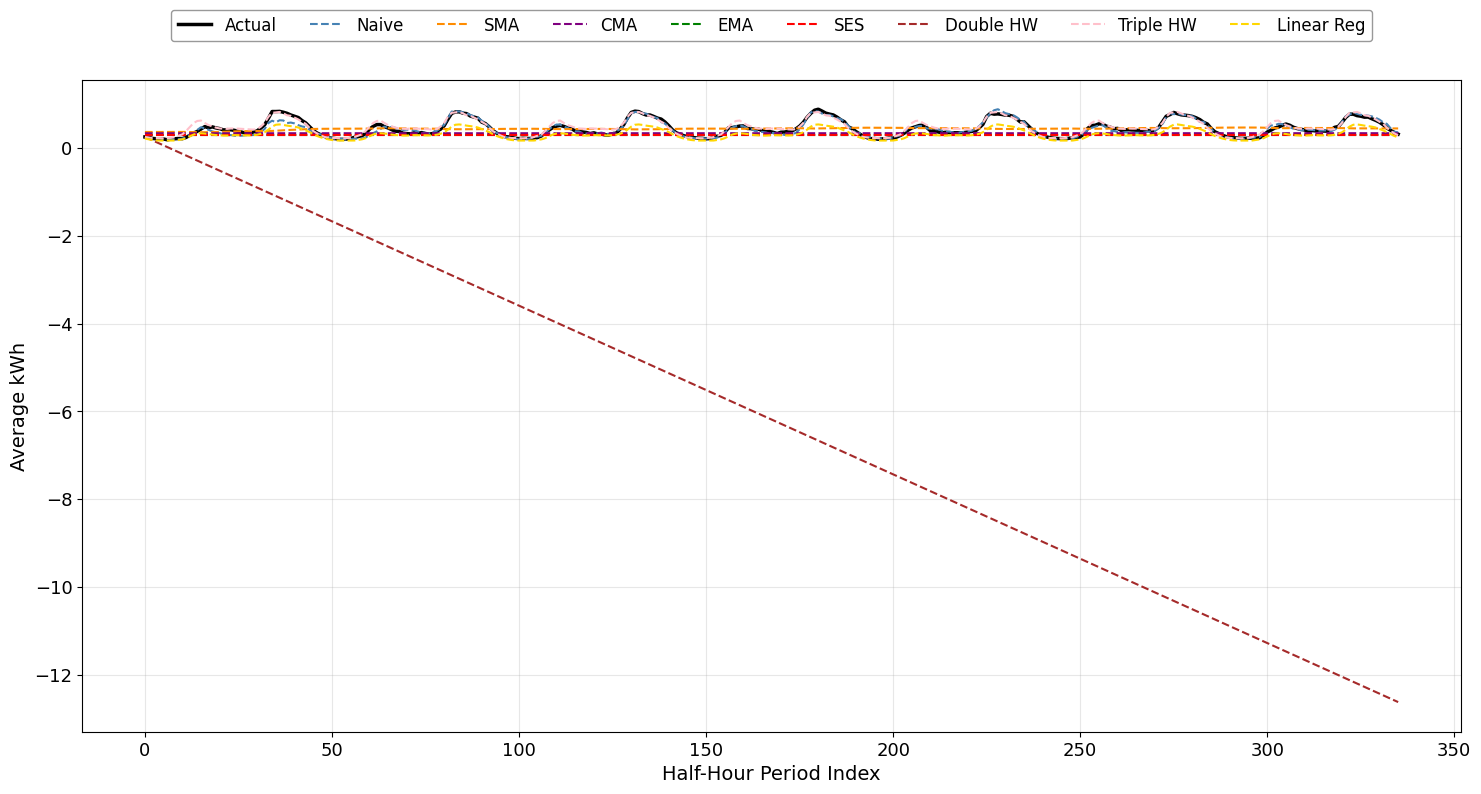

In [38]:
# ── Verification Plot — All Models vs Actual (First Week Year 3) ──

plt.figure(figsize=(15, 8))

plt.plot(test_naive['Avg_kWh'].values[:336],    label='Actual',          color='black',      linewidth=2.5)
plt.plot(test_naive['Naive'].values[:336],       label='Naive',           color='steelblue',  linewidth=1.5, linestyle='--')
plt.plot(test_sma['SMA_48'].values[:336],        label='SMA',             color='darkorange', linewidth=1.5, linestyle='--')
plt.plot(test_cma['CMA'].values[:336],           label='CMA',             color='purple',     linewidth=1.5, linestyle='--')
plt.plot(test_ema['EMA_best'].values[:336],      label='EMA',             color='green',      linewidth=1.5, linestyle='--')
plt.plot(test_ses['SES'].values[:336],           label='SES',             color='red',        linewidth=1.5, linestyle='--')
plt.plot(test_hw2['HWES2_ADD'].values[:336],     label='Double HW',       color='brown',      linewidth=1.5, linestyle='--')
plt.plot(test_hw3['HWES3_ADD'].values[:336],     label='Triple HW',       color='pink',       linewidth=1.5, linestyle='--')
plt.plot(test_lr['LR'].values[:336],             label='Linear Reg',      color='gold',       linewidth=1.5, linestyle='--')

plt.xlabel('Half-Hour Period Index', fontsize=14)
plt.ylabel('Average kWh', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Horizontal legend above the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=9,
    fontsize=12,
    frameon=True,
    edgecolor='gray'
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Comparing Model**

In [39]:
# ── Final Model Comparison Table ─────────────────────────────────

results = {
    'Naive (Benchmark)' : [Bias_naive, MAD_naive, MAPE_naive, RMSE_naive, TS_naive],
    'SMA'               : [Bias_sma,   MAD_sma,   MAPE_sma,   RMSE_sma,   TS_sma],
    'CMA'               : [Bias_cma,   MAD_cma,   MAPE_cma,   RMSE_cma,   TS_cma],
    'EMA'               : [Bias_ema,   MAD_ema,   MAPE_ema,   RMSE_ema,   TS_ema],
    'SES'               : [Bias_ses,   MAD_ses,   MAPE_ses,   RMSE_ses,   TS_ses],
    'Double HW'         : [Bias_hw2,   MAD_hw2,   MAPE_hw2,   RMSE_hw2,   TS_hw2],
    'Triple HW'         : [Bias_hw3,   MAD_hw3,   MAPE_hw3,   RMSE_hw3,   TS_hw3],
    'Linear Regression' : [Bias_lr,    MAD_lr,    MAPE_lr,    RMSE_lr,    TS_lr],
}

df_results = pd.DataFrame(results, index=['Bias', 'MAD', 'MAPE (%)', 'RMSE', 'TS']).T
df_results = df_results.round(4)

# Rank by RMSE (lower is better)
df_results['Rank (RMSE)'] = df_results['RMSE'].rank().astype(int)
df_results = df_results.sort_values('RMSE')

print("=" * 75)
print("FORECAST MODEL COMPARISON — Test Set (Year 3)")
print("=" * 75)
print(df_results.to_string())
print("=" * 75)

# Highlight best model
best_model = df_results['RMSE'].idxmin()
print(f"\nBest model by RMSE : {best_model}")
print(f"Best model by MAPE : {df_results['MAPE (%)'].idxmin()}")
print(f"Best model by MAD  : {df_results['MAD'].idxmin()}")

FORECAST MODEL COMPARISON — Test Set (Year 3)
                       Bias       MAD     MAPE (%)      RMSE      TS  Rank (RMSE)
Naive (Benchmark)   -0.0003    0.0365      10.7488    0.0699 -0.0069            1
Linear Regression    0.0152    0.0589      16.4419    0.0871  0.2585            2
SMA                  0.0001    0.0911      30.2558    0.1189  0.0012            3
CMA                 -0.0160    0.1011      35.2423    0.1302 -0.1587            4
EMA                  0.0283    0.0928      28.2062    0.1324  0.3044            5
SES                  0.0286    0.0928      28.1646    0.1325  0.3085            6
Triple HW           -0.1493    0.1562      51.5140    0.1919 -0.9557            7
Double HW          336.8301  336.8301  121323.9437  388.9193  1.0000            8

Best model by RMSE : Naive (Benchmark)
Best model by MAPE : Naive (Benchmark)
Best model by MAD  : Naive (Benchmark)


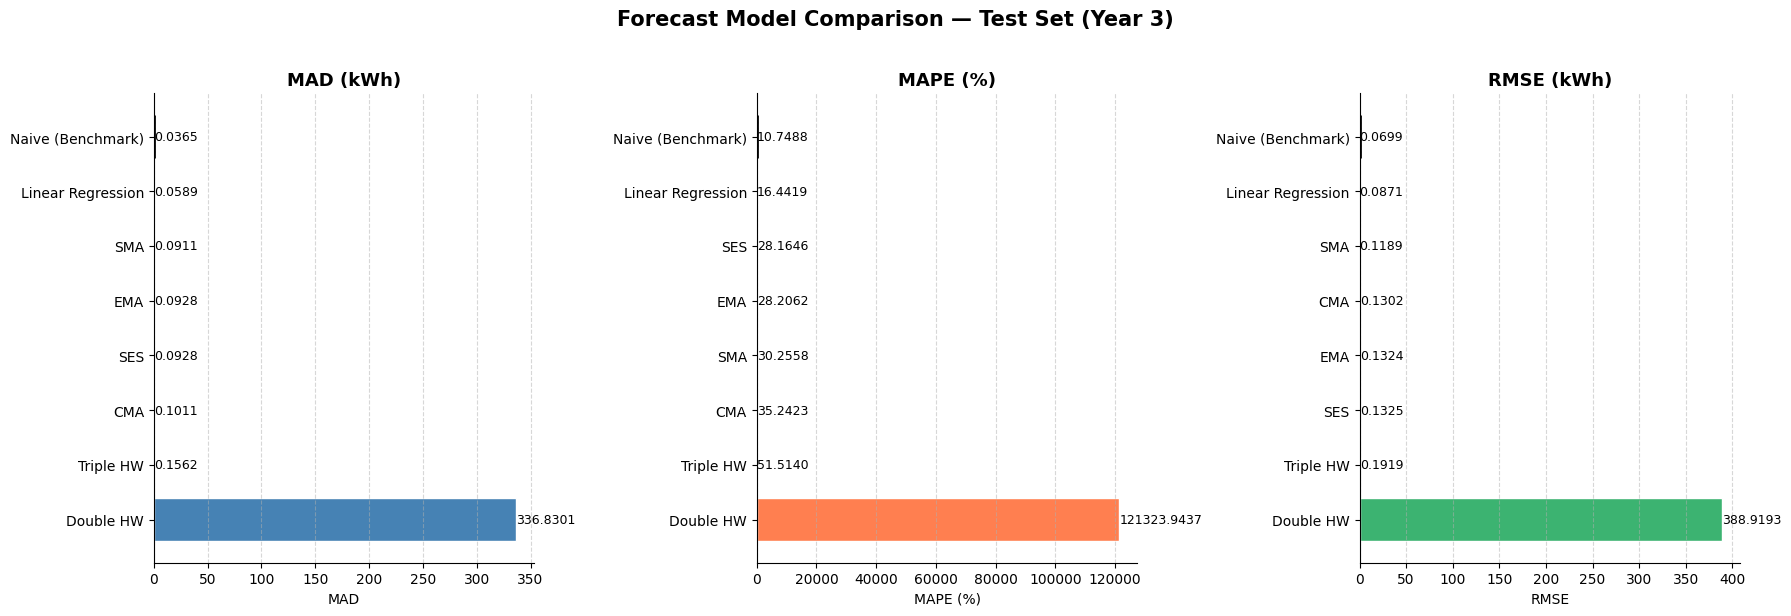

In [40]:
# ── Model Comparison Bar Chart ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['MAD', 'MAPE (%)', 'RMSE']
colors  = ['steelblue', 'coral', 'mediumseagreen']
titles  = ['MAD (kWh)', 'MAPE (%)', 'RMSE (kWh)']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    data = df_results[metric].sort_values()
    bars = ax.barh(data.index, data.values, color=color, edgecolor='white')

    # Add value labels on bars
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='left', fontsize=9)

    # Highlight naive as benchmark
    for bar, label in zip(bars, data.index):
        if label == 'Naive (Benchmark)':
            bar.set_edgecolor('black')
            bar.set_linewidth(2)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Forecast Model Comparison — Test Set (Year 3)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

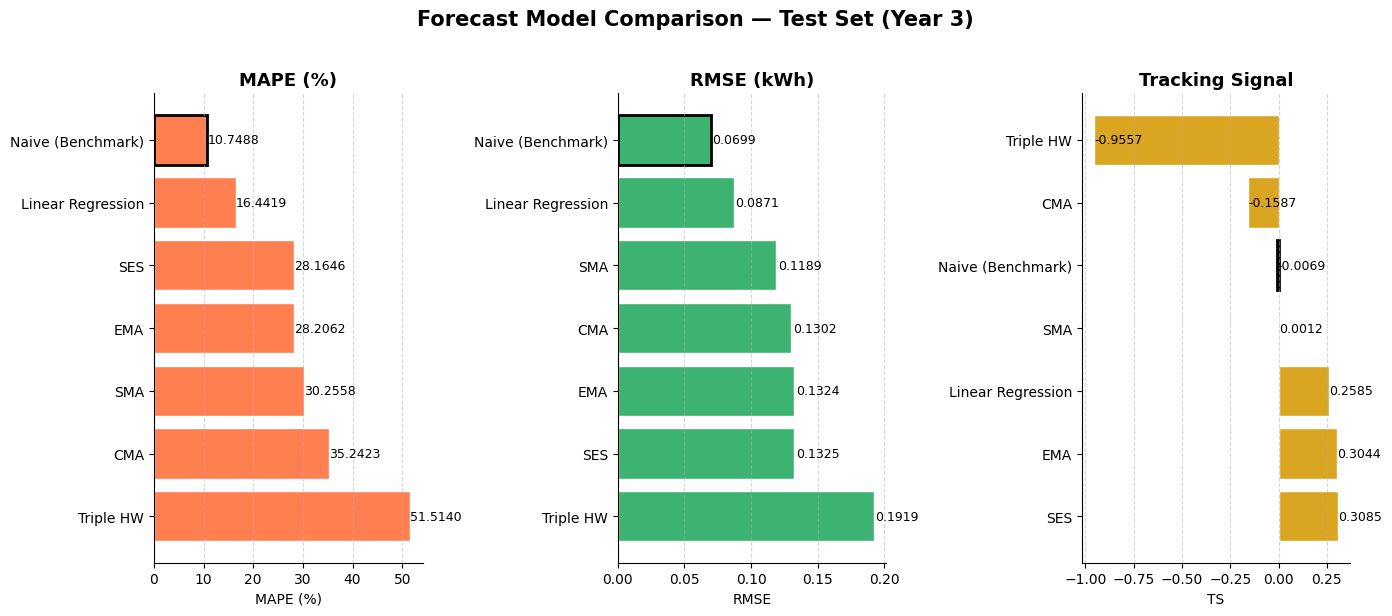

In [52]:
# ── Model Comparison Bar Chart ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

metrics = ['MAPE (%)', 'RMSE', 'TS']
colors  = ['coral', 'mediumseagreen', 'goldenrod']
titles  = [ 'MAPE (%)', 'RMSE (kWh)', 'Tracking Signal']

# Remove HW2 before plotting
df_plot = df_results[df_results.index != 'Double HW']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    data = df_plot[metric].sort_values()
    bars = ax.barh(data.index, data.values, color=color, edgecolor='white')

    # Add value labels on bars
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='left', fontsize=9)

    # Highlight Naive as benchmark
    for bar, label in zip(bars, data.index):
        if label == 'Naive (Benchmark)':
            bar.set_edgecolor('black')
            bar.set_linewidth(2)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Forecast Model Comparison — Test Set (Year 3)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

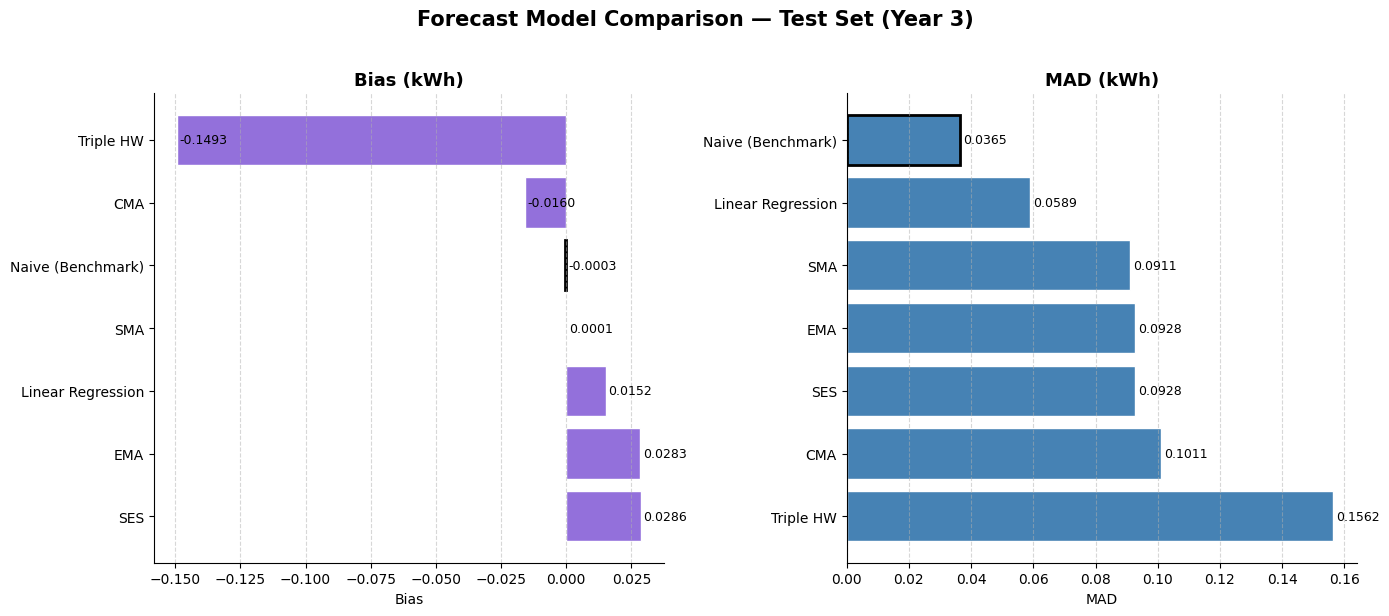

In [53]:
# ── Model Comparison Bar Chart ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['Bias', 'MAD']
colors  = ['mediumpurple', 'steelblue']
titles  = ['Bias (kWh)', 'MAD (kWh)']

# Remove HW2 before plotting
df_plot = df_results[df_results.index != 'Double HW']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    data = df_plot[metric].sort_values()
    bars = ax.barh(data.index, data.values, color=color, edgecolor='white')

    # Add value labels on bars
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='left', fontsize=9)

    # Highlight Naive as benchmark
    for bar, label in zip(bars, data.index):
        if label == 'Naive (Benchmark)':
            bar.set_edgecolor('black')
            bar.set_linewidth(2)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Forecast Model Comparison — Test Set (Year 3)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [43]:
print(df_results.index.tolist())

['Naive (Benchmark)', 'Linear Regression', 'SMA', 'CMA', 'EMA', 'SES', 'Triple HW', 'Double HW']


# **Forecasting Year 4**

In [ ]:
# ── Naive Forecast Year 4 ─────────────────────────────────────────

clean_full = df_long['Deseasonalized_kWh'].dropna()
last_day_naive = clean_full.iloc[-48:].tolist()

year4_periods = 365 * 48  # 17520

naive_year4 = []
window_naive = last_day_naive.copy()

for i in range(year4_periods):
    forecast = window_naive[-48]
    naive_year4.append(forecast)
    window_naive.append(forecast)

seasonal_cycle = [df_long['Seasonal_Index'].iloc[i % 48] for i in range(year4_periods)]

df_year4_naive = pd.DataFrame({
    'Period_Index': range(year4_periods),
    'Naive_Deseasonalized': naive_year4,
    'Seasonal_Index': seasonal_cycle,
})
df_year4_naive['Naive'] = df_year4_naive['Naive_Deseasonalized'] * df_year4_naive['Seasonal_Index']

# First week
plt.figure(figsize=(15, 6))
plt.plot(df_year4_naive['Naive'].values[:336], label='Naive Forecast (Year 4)', color='darkblue', linewidth=2)
plt.title('Naive Forecast — Year 4 First Week')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Naive Year 4 — min: {df_year4_naive['Naive'].min():.4f}, max: {df_year4_naive['Naive'].max():.4f}, mean: {df_year4_naive['Naive'].mean():.4f}")

In [ ]:
# ── SMA Forecast Year 4 ───────────────────────────────────────────

clean_full = df_long['Deseasonalized_kWh'].dropna()
seed_sma = clean_full.iloc[-47:].tolist()
window_sma = seed_sma.copy()

sma_year4 = []
for i in range(year4_periods):
    forecast = np.mean(window_sma)
    sma_year4.append(forecast)
    window_sma.append(forecast)
    window_sma.pop(0)

df_year4_sma = pd.DataFrame({
    'Period_Index': range(year4_periods),
    'SMA_Deseasonalized': sma_year4,
    'Seasonal_Index': seasonal_cycle,
})
df_year4_sma['SMA'] = df_year4_sma['SMA_Deseasonalized'] * df_year4_sma['Seasonal_Index']

# First week
plt.figure(figsize=(15, 6))
plt.plot(df_year4_sma['SMA'].values[:336], label='SMA Forecast (Year 4)', color='darkorange', linewidth=2)
plt.title('SMA Forecast — Year 4 First Week')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

print(f"SMA Year 4 — min: {df_year4_sma['SMA'].min():.4f}, max: {df_year4_sma['SMA'].max():.4f}, mean: {df_year4_sma['SMA'].mean():.4f}")

In [ ]:
# ── Triple HW Forecast Year 4 ─────────────────────────────────────
# Refit on all 3 years of raw Avg_kWh then forecast forward

full_hw3 = df_long['Avg_kWh'].dropna().reset_index(drop=True)

hw3_full_model = ExponentialSmoothing(
    full_hw3,
    trend='add',
    seasonal='add',
    seasonal_periods=48
).fit(optimized=True)

print(f"Alpha (level)   : {hw3_full_model.params['smoothing_level']:.4f}")
print(f"Beta  (trend)   : {hw3_full_model.params['smoothing_trend']:.4f}")
print(f"Gamma (seasonal): {hw3_full_model.params['smoothing_seasonal']:.4f}")

# Forecast 1 year ahead
year4_periods = 365 * 48
hw3_year4 = hw3_full_model.forecast(year4_periods).reset_index(drop=True)

df_year4_hw3 = pd.DataFrame({
    'Period_Index': range(year4_periods),
    'HWES3': hw3_year4.values
})

# First week
plt.figure(figsize=(15, 6))
plt.plot(df_year4_hw3['HWES3'].values[:336], label='Triple HW Forecast (Year 4)', color='green', linewidth=2)
plt.title('Triple HW Forecast — Year 4 First Week')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Full year - daily average
hw3_daily = df_year4_hw3['HWES3'].values.reshape(365, 48).mean(axis=1)
naive_daily = df_year4_naive['Naive'].values.reshape(365, 48).mean(axis=1)
sma_daily   = df_year4_sma['SMA'].values.reshape(365, 48).mean(axis=1)

plt.figure(figsize=(15, 6))
plt.plot(naive_daily, label='Naive (Year 4)', color='darkblue', linewidth=2)
plt.plot(sma_daily,   label='SMA (Year 4)',   color='darkorange', linewidth=2)
plt.plot(hw3_daily,   label='Triple HW (Year 4)', color='green', linewidth=2)
plt.title('Year 4 Forecast — Full Year Daily Average (All 3 Models)')
plt.xlabel('Day')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()